# XMLD Ptycho notebook
First generate code to simulate the speckle pattern for a Neel texture for several given probes (of different linear polarisations).
* The sample (object) is now represented by pixels each of which is a complex Jones Matrix. This Jones matrix is able to act on different polarisations differently
* The Jones Matrix is constructed from a Neel field (parametrised by $\theta$ and $\phi$)
* Several probes are now needed, each with a different Jones vector
* A tensor of diffraction patterns are now collected of shape 

In [20]:
from vector_ptycho.utils import *
import numpy as np
import matplotlib.pyplot as plt
import torch


theta range: [0.291, 2.851]
phi range: [0.001, 6.282]
Mx range: [-1.000, 1.000]
My range: [-1.000, 1.000]
Mz range: [-0.958, 0.958]


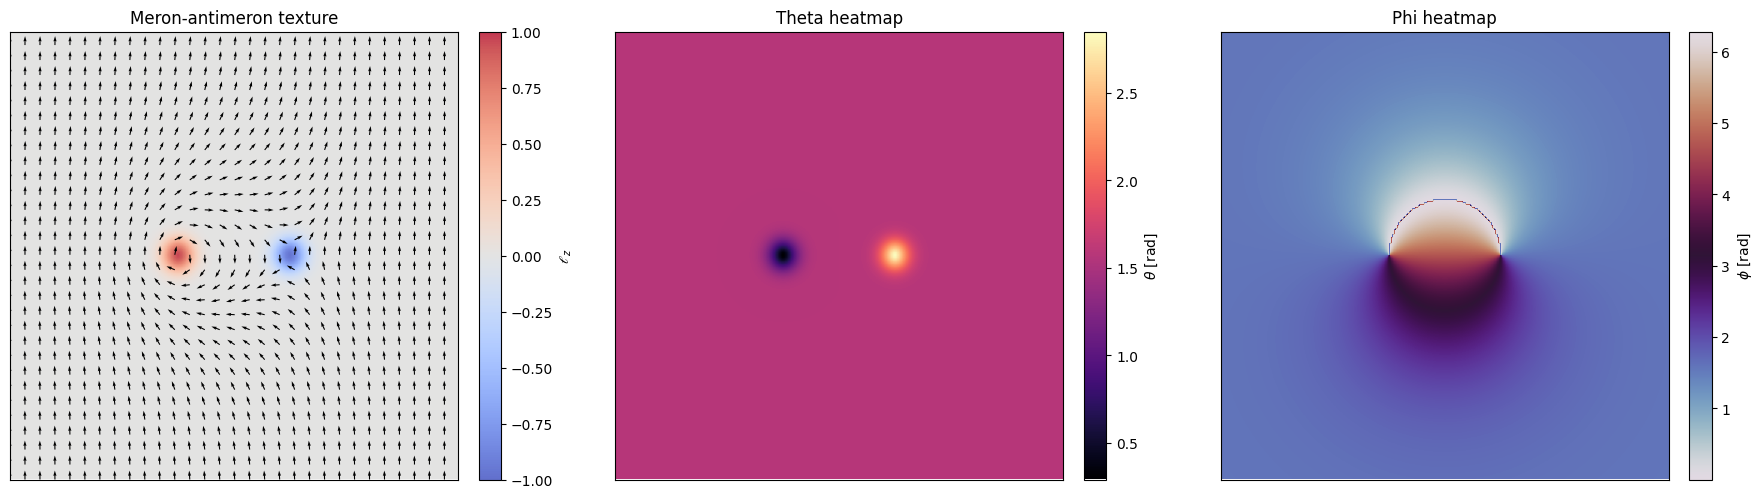

theta range: [0.291, 2.851]
phi range: [0.001, 6.282]
Mx range: [-1.000, 1.000]
My range: [-1.000, 1.000]
Mz range: [-0.958, 0.958]
Jones object built with shape: torch.Size([300, 300, 2, 2])
Jones object dtype: torch.complex64
An example Jones matrix at the center pixel:
 tensor([[1.0004+0.5004j, 0.0080-0.0080j],
        [0.0080-0.0080j, 1.4996+0.9996j]])


In [82]:
# =========================
# Example usage
# =========================
H, W = 300, 300
Lx = 10
Ly = 10

# Build theta, phi from meron-antimeron generator (returns torch tensors)
theta, phi, Mx, My, Mz = make_meron_antimeron_theta_phi(
    Nx=W,
    Ny=H,
    Lx=Lx,
    Ly=Ly,
    plot=True,
    save_path=None,
    export_path=None,
    return_torch=True,
    out_device=device,
)

print('theta range: [{:.3f}, {:.3f}]'.format(theta.min().item(), theta.max().item()))
print('phi range: [{:.3f}, {:.3f}]'.format(phi.min().item(), phi.max().item()))

print('Mx range: [{:.3f}, {:.3f}]'.format(Mx.min().item(), Mx.max().item()))
print('My range: [{:.3f}, {:.3f}]'.format(My.min().item(), My.max().item()))
print('Mz range: [{:.3f}, {:.3f}]'.format(Mz.min().item(), Mz.max().item()))

# Physical XMLD/Jones constants
C = torch.tensor(1.0 + 0.5j, dtype=cdtype, device=device)
A1 = torch.tensor(0.5 + 0.5j, dtype=cdtype, device=device)
A2 = torch.tensor(-0.3 + 0.3j, dtype=cdtype, device=device)

# Build Jones object from theta, phi
neel = NeelObject(C, A1, A2)
J = neel.build_jones(theta, phi)
obj = JonesObject(J)
print('Jones object built with shape:', J.shape)
print('Jones object dtype:', J.dtype)
print('An example Jones matrix at the center pixel:\n', J[H//2, W//2])



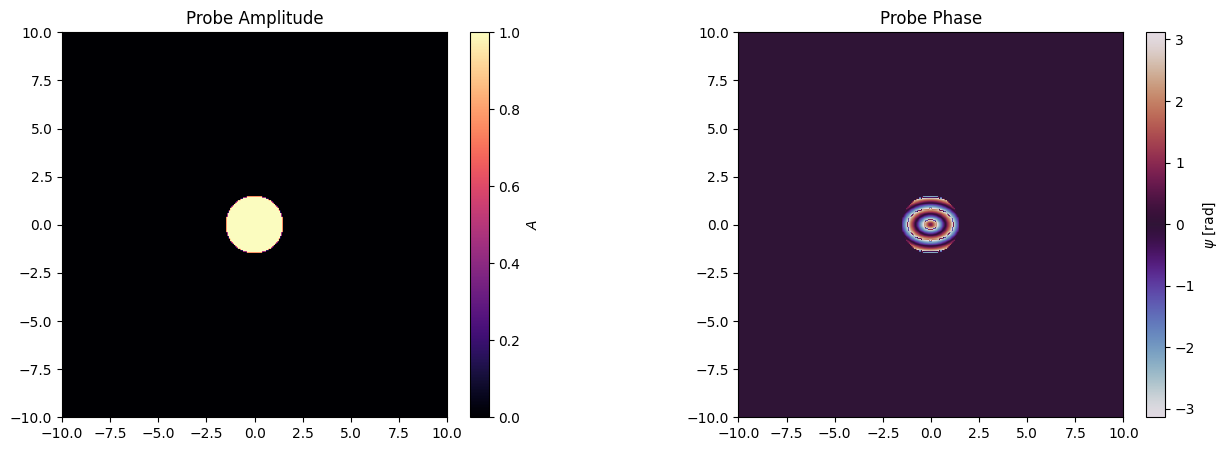

Jones vector for 0 deg linear polarisation: tensor([1.+0.j, 0.+0.j])
Jones vector for 30 deg linear polarisation: tensor([0.8660+0.j, 0.5000+0.j])
Jones vector for 60 deg linear polarisation: tensor([0.5000+0.j, 0.8660+0.j])
Jones vector for 90 deg linear polarisation: tensor([6.1232e-17+0.j, 1.0000e+00+0.j])
Defined 4 probes with different linear polarisation states.


In [83]:
# Grid for probe definition
x = torch.linspace(-Lx, Lx, H, device=device)
y = torch.linspace(-Ly, Ly, W, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')


R=torch.sqrt(X**2+Y**2) #This helps with defining the probe

Diffuser = (torch.sqrt(3*X**2+1.5*Y**2)+torch.pi/3)*(R<=1.5) #np.mod(0.1*(torch.sin(150*R)+torch.cos((Y*10+X*30)**2-0.8*(X*75-0.2))+torch.cos((Y*10-X*33)**2-0.4*(X*50-0.2))),1)

P = torch.zeros_like(R)
P = torch.exp(2j*np.pi*Diffuser)*(R<=1.5)

# Plot the scan positions on top of the theta and phi maps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Panel 1: theta heatmap
im1 = axes[0].imshow(torch.abs(P).cpu(), extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='magma')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label(r'$A$')
axes[0].set_title('Probe Amplitude')

# Panel 2: phi heatmap
im2 = axes[1].imshow(torch.angle(P).cpu(), extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='twilight')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label(r'$\psi$ [rad]')
axes[1].set_title('Probe Phase')
plt.show()

probes = []
# Calculate the Jones vectors of the probes for different Linear polarisation states
for angle in [0, 30, 60, 90]:
    rad = np.deg2rad(angle)
    jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
    print(f'Jones vector for {angle} deg linear polarisation: {jones_vec}')
    probes.append(Probe(P, jones_vec))

print('Defined {} probes with different linear polarisation states.'.format(len(probes)))



C:\Users\godfrey\OneDrive - Nexus365\Documents\Google Drive (old computer 12_07_2022)\PhD\Year 3\Term 1\Ptycho\vector-ptycho\src\vector_ptycho\utils.py:185: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.positions = torch.tensor(positions, device=device)


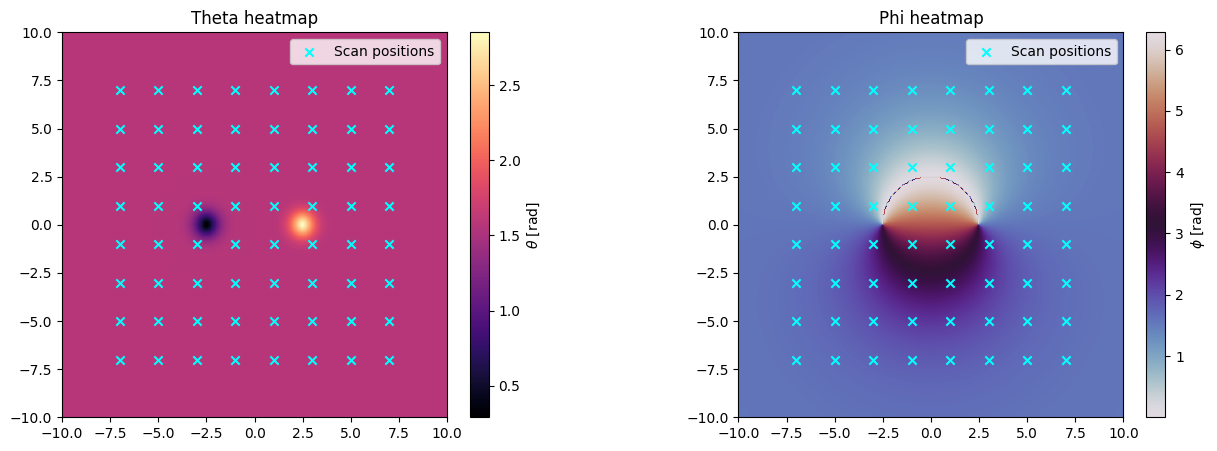

"\n# Forward model\nmodel = ForwardModel(obj, Propagator(), Detector())\n\nI_sim = model.simulate_all(probes, scan)\nprint('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)\n\n# =========================\n# Convert back Jones -> Neel\n# =========================\ntheta_rec, phi_rec = jones_to_neel(J)\nprint('Recovered theta shape:', theta_rec.shape)\n"

In [84]:
xshiftvec = torch.linspace(-7, 7, 8)
yshiftvec = torch.linspace(-7, 7, 8)

ypos, xpos = torch.meshgrid(yshiftvec, xshiftvec, indexing="ij")

# Stack into (N, 2) list of coordinate pairs
positions = torch.stack([ypos.flatten(), xpos.flatten()], dim=1)

# Convert to integer pixel shifts (important for indexing/rolling)
positions = positions.to(torch.int64)

scan = ScanTrajectory(positions)

# Plot the scan positions on top of the theta and phi maps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Panel 1: theta heatmap
im1 = axes[0].imshow(theta, extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='magma')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label(r'$\theta$ [rad]')
axes[0].set_title('Theta heatmap')
#axes[0].set_xticks([])
#axes[0].set_yticks([])
axes[0].scatter(positions[:, 1].cpu(), positions[:, 0].cpu(), c='cyan', marker='x', label='Scan positions')
axes[0].legend(loc='upper right')

# Panel 2: phi heatmap
im2 = axes[1].imshow(phi, extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='twilight')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label(r'$\phi$ [rad]')
axes[1].set_title('Phi heatmap')
#axes[1].set_xticks([])
#axes[1].set_yticks([])
axes[1].scatter(positions[:, 1].cpu(), positions[:, 0].cpu(), c='cyan', marker='x', label='Scan positions')
axes[1].legend(loc='upper right')
plt.show()
'''
# Forward model
model = ForwardModel(obj, Propagator(), Detector())

I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

# =========================
# Convert back Jones -> Neel
# =========================
theta_rec, phi_rec = jones_to_neel(J)
print('Recovered theta shape:', theta_rec.shape)
'''

In [85]:
# Forward model
model = ForwardModel(obj, Propagator(), Detector())
I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

Simulated data shape: torch.Size([4, 64, 300, 300])


C:\Users\godfrey\AppData\Local\Temp\ipykernel_17552\2131334272.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(I_sim[probe_number, scan_idx].cpu() + 1e-8),


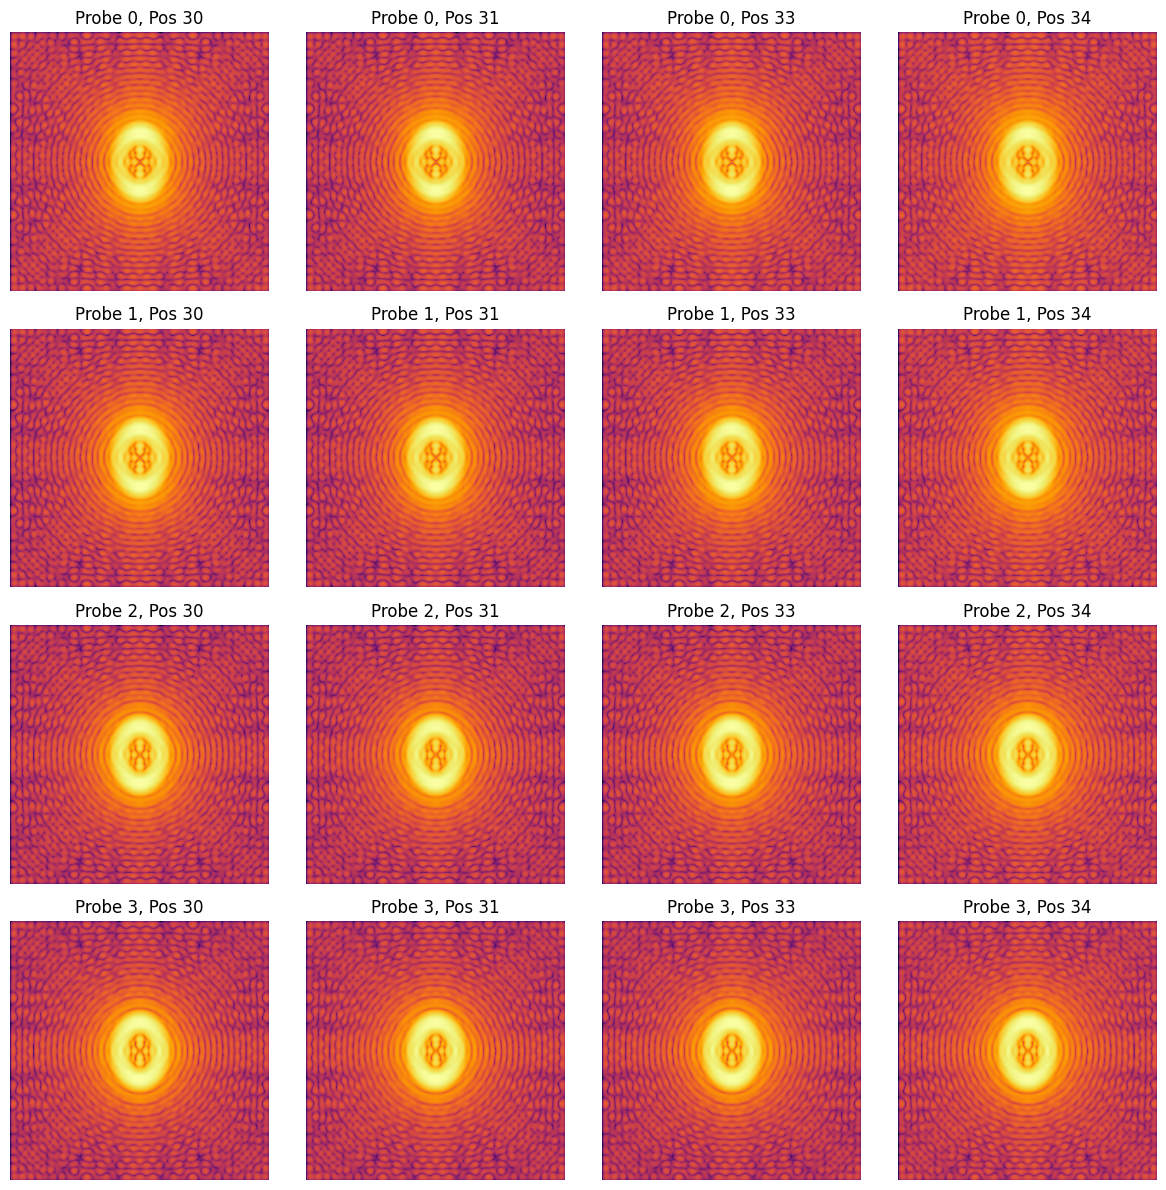

In [86]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

scan_indices = [30, 31, 33, 34]
probe_numbers = [0, 1, 2, 3]

for i, probe_number in enumerate(probe_numbers):      # rows
    for j, scan_idx in enumerate(scan_indices):       # columns

        axes[i, j].imshow(
            np.log10(I_sim[probe_number, scan_idx].cpu() + 1e-8),
            cmap='inferno'
        )

        axes[i, j].set_title(f'Probe {probe_number}, Pos {scan_idx}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()